In [1]:

import torch 
import numpy as np

import time 
import logging 
import argparse 
import sys, os
from datetime import datetime 
from rockets import RocketDynamics
from hj_adaptive_descent import HJ_MAD
from os.path import join, expanduser 

import matplotlib
%matplotlib inline 


import matplotlib.pyplot as plt

## Problem Statement and Numerical Setting

Let $\Omega = [0,L]\subset \mathbb{R}$ be the spatial domain indicated by the variable $\omega$, and let $(0,T]\subset\mathbb{R}$ be the time domain with variable $t$.
We consider the three-dimensional HJ equation with homogeneous Dirichlet boundary conditions,
$$
\begin{align*}
    &\partial \bm{v}_t(t; \bm{x}) + \min\{0, \bm{H}\left(x, \partial \bm{v}_{\bm{x}}(t; \bm{x})\right)\} = 0, \qquad &\bm{v}(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%\bm{v}(0; \bm{x}) &= \bm{g}(0; \bm{x}) \\
%
&\approx \partial \bm{v}^\delta_t(t; \bm{x}) + \min\{0, 
\bm{H}^\delta\left(t; x, \partial \bm{v}^\delta_{\bm{x}}\right)\} = 0, \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%
&:= \partial \bm{v}^\delta_t(t; \bm{x}) + \min\bigg\{0, 
\max_{\bm{u} \in \mathcal{U}} \min_{\bm{w} \in \mathcal{W}} \, \bigg\langle f(t; \bm{x}, \bm{u}, \bm{w}), \frac{1}{t}(\bm{x} - \text{prox}_{t\bm{g}}(\bm{x})) \bigg\rangle
\bigg\} = 0 \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}).
\end{align*}
$$

This is a model for a one-dimensional rod that conducts heat: the temperature at the ends of the rod are fixed at $0$ and heat is allowed to flow out of the rod through the ends.

In [2]:

class Bundle(object):
    def __init__(self, dicko):
        """
            This class creates a Bundle similar to matlab's
            struct class.
        """
        for var, val in dicko.items():
            object.__setattr__(self, var, val)

    def __dtype__(self):
        return Bundle

    def __len__(self):
        return len(self.__dict__.keys())

    def keys():
        return list(self.__dict__.keys())

In [3]:
args = Bundle(dict(verbose=False, adapt_time=True, resolution=1000, 
                   time_upper=1, spatial_bound=64, seed=123, num_samples=100, data_dir="/opt/hj_reach",
                   experiment='prox_reach', num_trials=100))

logger = logging.getLogger(__name__)

resolution = 100; L = 100
dynamics = RocketDynamics(1, 1, T=args.time_upper, L=args.spatial_bound, a=32, g=32, resolution=args.resolution)
states =  dynamics.state_space

seed = 123
torch.manual_seed(seed)
np.random.seed(seed)

x_all = dynamics.state_space
x0 = dynamics.get_initial_conditions()

target_region_size = resolution//4
'set target region as top quadrant of the state space'
x_true = torch.zeros_like(x0)
x_true[:target_region_size, 0] = x_all[:target_region_size, 0]
x_true[:target_region_size, 1] = x_all[:target_region_size, 1]
x_true[:target_region_size, 2] = x_all[:target_region_size, 2]

max_iters       = int(5e4)

eps= sys.float_info.epsilon
t_span = [eps, 1.0]

In [4]:
# hj_mad_algo = HJ_MAD(dynamics, delta=0.1, int_samples=args.num_samples, t_span = t_span, max_iters=max_iters, 
#                                     tol=5e-2, psi=0.01, beta=0.9, alpha=1.0, adapt_time=True, verbose=True)

# # run 30 times 
# avg_func_evals  = 0

# x_opt_list, xk_hist_list, tk_hist_list, xk_error_hist_list, \
#     rel_grad_uk_norm_hist_list, globalk_hist_list = [[np.nan for x in range(args.num_trials)]]*6

# # no elems
# x_opt_list, xk_hist_list, tk_hist_list, xk_error_hist_list, \
#     rel_grad_uk_norm_hist_list, gk_hist_list = [[]]*6

# save_path = join(args.data_dir, args.experiment)
# if not os.path.exists(save_path):
#     os.makedirs(save_path)

# for trial in range(args.num_trials):
#     print(f">>>Rolling on sample trial {trial}/{args.num_trials}.")
#     x_opt, xk_hist, tk_hist, xk_error_hist, \
#         rel_grad_uk_norm_hist, gk_hist = hj_mad_algo.run()

# # stack em results
# x_opt_list += x_opt 
# xk_hist_list += xk_hist
# tk_hist_list += tk_hist
# xk_error_hist_list += xk_error_hist
# rel_grad_uk_norm_hist_list += rel_grad_uk_norm_hist
# gk_hist_list += gk_hist

# avg_func_evals += len(xk_error_hist)*args.num_samples

# fname = join(save_path, datetime.strftime(datetime.now(), '%m_%d_%y-%H_%M_%S')+'.npz')
# print([type(A) for A in (tk_hist[-1], xk_hist[-1], xk_error_hist[-1], rel_grad_uk_norm_hist[-1], gk_hist[-1])])
# np.savez_compressed(fname, t_hist=np.asarray(tk_hist), x_hist=np.asarray(xk_hist), \
#                     delta_x=np.asarray(xk_error_hist), heat_kernel=np.asarray(rel_grad_uk_norm_hist), value_func=np.asarray(gk_hist))

# avg_func_evals = avg_func_evals/args.num_trials

# print('\n avg_func_evals = ', avg_func_evals)

## Load the saved file 

In [5]:
savedf = np.load('/opt/prox_reach/04_10_25-05_19_17/trial_0_evals_76600.npz')

t_hist=savedf['t_hist']
x_hist= savedf['x_hist']
delta_x= savedf['delta_x']
heat_kernel= savedf['heat_kernel'] 
value_func = savedf['value_func']

In [17]:
value_func.shape 

(767,)

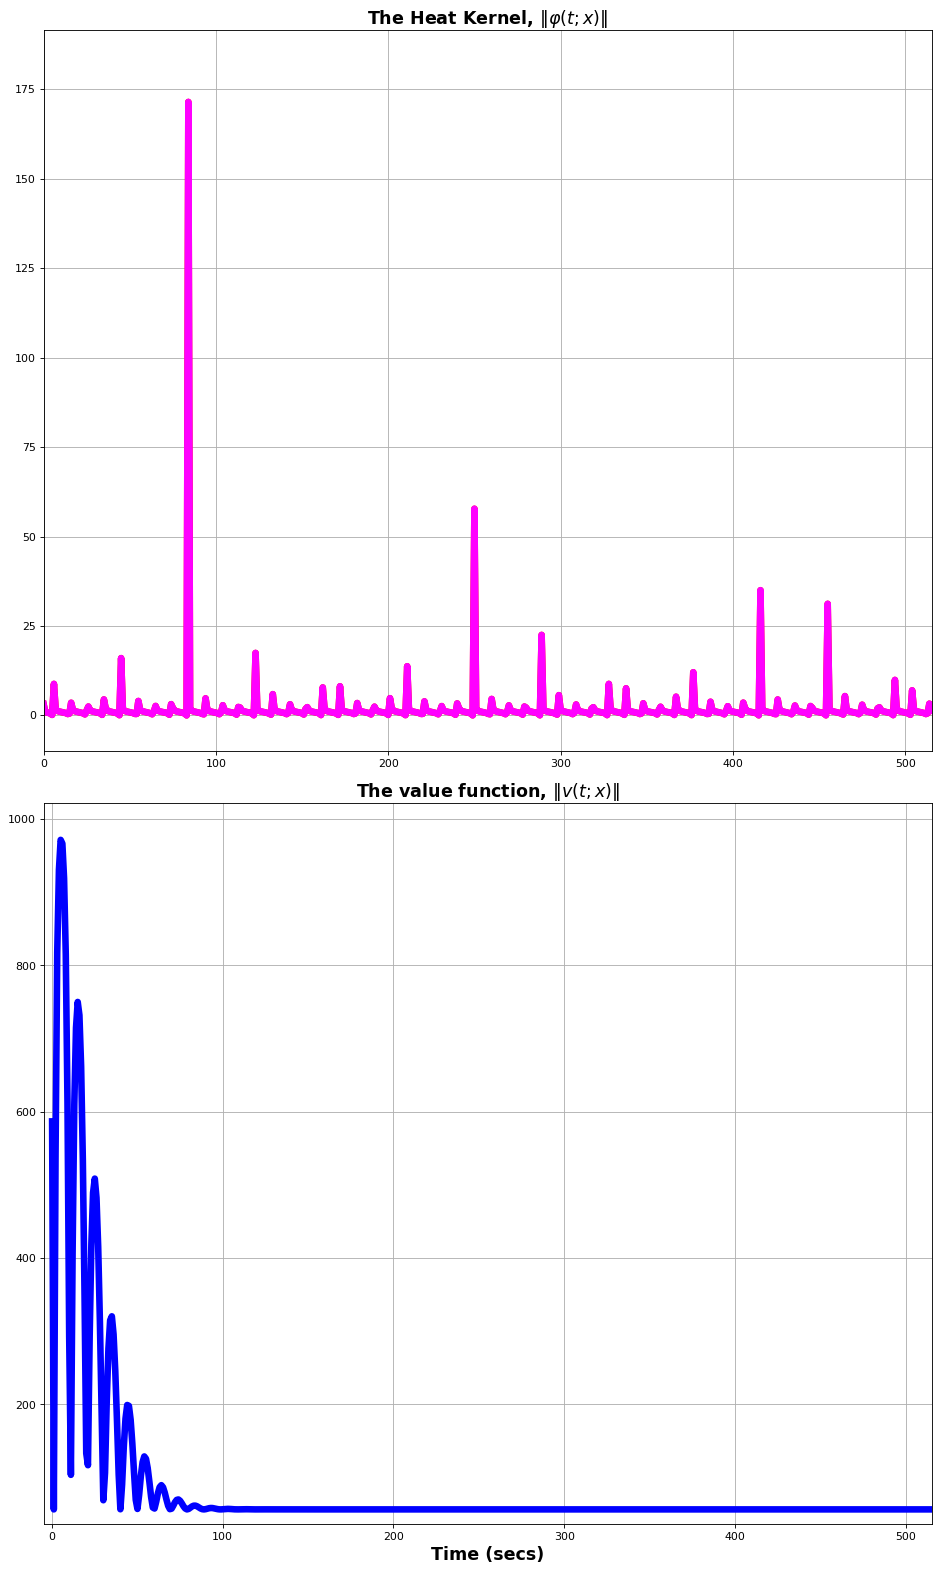

In [102]:
fontdict={'fontsize':16, 'fontweight':'bold'}

plt.close()
# plt.clf(); plt.cla()
fig = plt.figure(figsize=(12, 20), dpi=79)
color = iter(plt.cm.magma_r(np.linspace(0, 1, 3)))

# indices = np.arange(0, x_hist.shape[0], 7, dtype=np.intp)
# X, Z, θ =  np.meshgrid(*(x_hist[indices, 0], x_hist[indices, 1], x_hist[indices, 2]), indexing='ij', sparse=True) 
# X, Z, θ  = [x.squeeze() for x in (X, Z, θ )]
# # print(X.shape, Z.shape,  θ.shape )
# ax = fig.add_subplot(311, projection='3d')
# cdata = ax.scatter(X, Z, θ, c=value_func[indices], cmap="magma")
# plt.colorbar(cdata, ax=ax, extend="both", shrink=0.5)
# ax.set_xlim(t_hist.min(), t_hist.max())
# ax.set_ylim(x_hist.flatten().min(), x_hist.flatten().max())
# ax.set_xlabel(r"Time (secs)")
# ax.set_ylabel(r"States")
# ax.grid('on')
# ax.tick_params(axis='both', which='major', labelsize=10)
# # ax.legend(loc=(1.05, .05))
# ax.spines["right"].set_visible(False)
# ax.spines["top"].set_visible(False)
# ax.set_title("The Rockets Problem")
# # ax.


ax = fig.add_subplot(211)
ax.set_title("The Heat Kernel")
ax.plot(heat_kernel, color='red', linewidth=6, label=rf'$\|\bm{{x}}\|')
ax.set_title(rf"The Heat Kernel, ${{ \| \varphi(t; x) \|}}$", fontdict=fontdict)
ax.plot(heat_kernel, color='magenta', linewidth=6, label=rf'$\|\bm{{x}}\|')
ax.set_xlim(t_hist.min(), t_hist.max())
ax.set_ylim(heat_kernel.min()-10, heat_kernel.max()+20)
ax.grid('on')
# ax.set_xlabel(r"Time (secs)", fontdict=fontdict)

ax = fig.add_subplot(212)
ax.set_title(f"The Value, ${{ \bm{{v}}(t; x) }}")
ax.set_title(rf"The value function, ${{ \|v(t; x)\| }}$", fontdict=fontdict)
ax.plot(value_func[1:], color='blue', linewidth=6, label=rf'$\|\bm{{x}}\|')
ax.set_xlim(t_hist.min()-5, t_hist.max())
ax.set_ylim(value_func[1:].min()-20, value_func[1:].max()+50)
ax.set_xlabel(r"Time (secs)", fontdict=fontdict)
ax.grid('on')
# ax.axes.get_xaxis().set_ticks([])
# ax.axes.get_yaxis().set_ticks([])
plt.tight_layout()

In [75]:
value_func.max()

np.float64(1000000000.0)